# CIFAR-100 — WideResNet-28-4

Training **WideResNet-28-4** (Zagoruyko & Komodakis, 2016) from scratch on CIFAR-100.

WRN-28-10 is the established CIFAR-100 benchmark architecture. It is only 28 layers deep but uses
a **width multiplier of 4**, giving 64/128/256 channels per group instead of the standard 16/32/64.
This is more effective than going deeper at 32×32 because wider feature maps carry more
representational capacity without collapsing spatial dimensions to 2×2.

| Property | Value |
|---|---|
| Architecture | WideResNet-28-4 |
| Parameters | ~5.9 M |
| Dataset | CIFAR-100 (native 32×32) |
| Augmentation | RandAugment + RandomErasing |
| Scheduler | CosineAnnealingLR |
| Expected accuracy | 78–80% |

In [10]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler

sys.path.append('../..')
from utils import (
    get_cifar100_dataloaders, CIFAR100_CLASSES,
    fit, test_accuracy,
    plot_training_curves,
    ModelCheckpoint,
)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU   : {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
  GPU   : NVIDIA GeForce RTX 5070 Ti
  Memory: 17.1 GB


## Model Architecture

```
Input (3×32×32)
  └─ Conv 3×3  →  16 ch
  └─ Group 1   →  160 ch  (4 WideResBlocks, stride 1)   32×32
  └─ Group 2   →  320 ch  (4 WideResBlocks, stride 2)   16×16
  └─ Group 3   →  640 ch  (4 WideResBlocks, stride 2)    8×8
  └─ BN → ReLU → GlobalAvgPool → FC(640→100)
```

Each **WideResBlock** uses pre-activation (BN→ReLU→Conv) with Dropout between the two convolutions.


In [12]:
class WideResBlock(nn.Module):
    """Pre-activation wide residual block with dropout."""

    def __init__(self, in_ch, out_ch, stride=1, dropout=0.3):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.drop  = nn.Dropout(p=dropout)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.shortcut = (
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
            if stride != 1 or in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        out = self.drop(self.conv1(F.relu(self.bn1(x))))
        out = self.conv2(F.relu(self.bn2(out)))
        return out + self.shortcut(x)


class WideResNet(nn.Module):
    """
    WideResNet-depth-width_factor.
    Default: WRN-28-10, ~36.5M params, CIFAR-100 SotA baseline.

    Reference: Zagoruyko & Komodakis (2016) https://arxiv.org/abs/1605.07146
    """

    def __init__(self, depth=28, width=10, num_classes=100, dropout=0.3):
        super().__init__()
        assert (depth - 4) % 6 == 0, 'depth must satisfy (depth-4) % 6 == 0'
        n  = (depth - 4) // 6          # blocks per group
        ch = [16, 16*width, 32*width, 64*width]

        self.conv1  = nn.Conv2d(3, ch[0], 3, stride=1, padding=1, bias=False)
        self.layer1 = self._group(ch[0], ch[1], n, stride=1, dropout=dropout)
        self.layer2 = self._group(ch[1], ch[2], n, stride=2, dropout=dropout)
        self.layer3 = self._group(ch[2], ch[3], n, stride=2, dropout=dropout)
        self.bn     = nn.BatchNorm2d(ch[3])
        self.fc     = nn.Linear(ch[3], num_classes)
        self._init()

    def _group(self, in_ch, out_ch, n, stride, dropout):
        layers = [WideResBlock(in_ch, out_ch, stride=stride, dropout=dropout)]
        for _ in range(1, n):
            layers.append(WideResBlock(out_ch, out_ch, stride=1, dropout=dropout))
        return nn.Sequential(*layers)

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.zeros_(m.bias)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.relu(self.bn(out))
        out = F.adaptive_avg_pool2d(out, 1).flatten(1)
        return self.fc(out)

In [13]:
# Tune width here: 2 (~1.5M), 4 (~5.9M), 6 (~13M), 10 (~36.5M)
DEPTH, WIDTH = 28, 6

model = WideResNet(depth=DEPTH, width=WIDTH, num_classes=100, dropout=0.3).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total:,}')
print(f'Trainable parameters: {trainable:,}')

# Sanity-check forward pass
dummy = torch.randn(2, 3, 32, 32, device=device)
print(f'Output shape: {model(dummy).shape}  (expected [2, 100])')

Total parameters:     13,179,444
Trainable parameters: 13,179,444
Output shape: torch.Size([2, 100])  (expected [2, 100])


## Data

Using **CIFAR-100 native normalisation stats** (not ImageNet) since we are training from scratch.
Augmentation: `RandAugment(ops=2, mag=9)` + `RandomErasing(p=0.25)`.


In [14]:
batch_size = 128  # Safe for 36.5M params on RTX 5070 Ti
epochs     = 200  # WRN converges slowly — 200 is the standard benchmark

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    use_imagenet_stats=False,   # native CIFAR-100 stats for scratch training
)
print(f'Train batches : {len(trainloader)}')
print(f'Val batches   : {len(valloader)}')
print(f'Test batches  : {len(testloader)}')

Train batches : 313
Val batches   : 79
Test batches  : 79


## Training

Standard WRN hyperparameters from the original paper:
- **SGD** with Nesterov momentum, `lr=0.1`, `weight_decay=5e-4`
- **CosineAnnealingLR**: smooth LR decay from 0.1 → 1e-6 over 200 epochs
- **AMP** (float16) for faster training


In [15]:
criterion = nn.CrossEntropyLoss()
scaler    = GradScaler('cuda')

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6,
)

checkpoint = ModelCheckpoint(
    model,
    checkpoint_path='../../checkpoint/wrn28_6_cifar100_last.pth',
    best_model_path='../../checkpoint/wrn28_6_cifar100_best.pth',
    mode='max',
    verbose=True,
)

print(f'Optimizer : SGD (Nesterov), lr=0.1, wd=5e-4')
print(f'Scheduler : CosineAnnealingLR, T_max={epochs}')
print(f'Epochs    : {epochs} | Batch size: {batch_size}')

Optimizer : SGD (Nesterov), lr=0.1, wd=5e-4
Scheduler : CosineAnnealingLR, T_max=200
Epochs    : 200 | Batch size: 128


In [16]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
    step_scheduler_per_batch=False,
)

[ModelCheckpoint] New best (max): 9.7000 — saved to ..\checkpoint\wrn28_6_cifar100_best.pth
Epoch [ 1/200]  Train Loss: 4.1834  Val Loss: 3.9086  Val Acc: 9.70%  LR: 0.099994  Time: 30.14s
[ModelCheckpoint] New best (max): 14.3700 — saved to ..\checkpoint\wrn28_6_cifar100_best.pth
Epoch [ 2/200]  Train Loss: 3.6962  Val Loss: 3.9767  Val Acc: 14.37%  LR: 0.099975  Time: 12.85s
[ModelCheckpoint] New best (max): 19.1400 — saved to ..\checkpoint\wrn28_6_cifar100_best.pth
Epoch [ 3/200]  Train Loss: 3.2854  Val Loss: 3.6036  Val Acc: 19.14%  LR: 0.099944  Time: 12.86s
Epoch [ 4/200]  Train Loss: 2.9666  Val Loss: 5.7547  Val Acc: 13.20%  LR: 0.099901  Time: 12.86s
[ModelCheckpoint] New best (max): 23.8600 — saved to ..\checkpoint\wrn28_6_cifar100_best.pth
Epoch [ 5/200]  Train Loss: 2.7345  Val Loss: 3.9693  Val Acc: 23.86%  LR: 0.099846  Time: 12.87s
[ModelCheckpoint] New best (max): 24.6000 — saved to ..\checkpoint\wrn28_6_cifar100_best.pth
Epoch [ 6/200]  Train Loss: 2.5537  Val Loss: 3

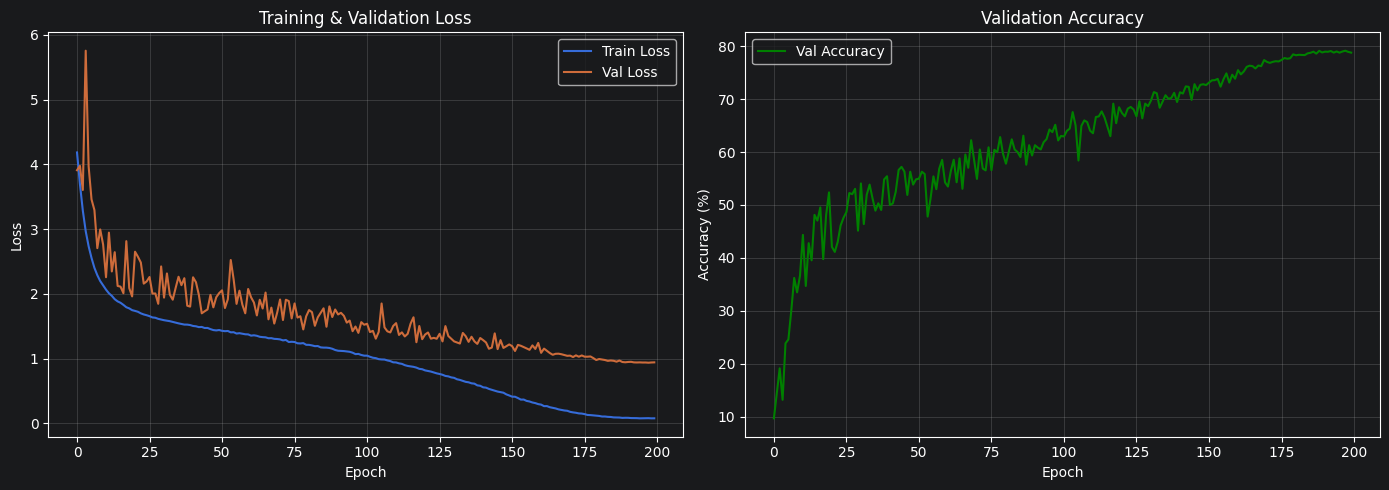

In [17]:
plot_training_curves(train_losses, val_losses, val_accuracies)

## Test Evaluation

Load the best checkpoint saved during training and evaluate on the held-out test set.


In [18]:
# Load best checkpoint weights
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'Test Accuracy: {overall_acc:.2f}%\n')

print('Per-class accuracies (sorted by accuracy):')
sorted_classes = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
for cls, acc in sorted_classes:
    bar = '█' * int(acc / 5)
    print(f'  {cls:<20s} {acc:5.1f}%  {bar}')

[ModelCheckpoint] Restored best weights from ..\checkpoint\wrn28_6_cifar100_best.pth (score=79.1400)
Test Accuracy: 78.68%

Per-class accuracies (sorted by accuracy):
  motorcycle            98.0%  ███████████████████
  road                  97.0%  ███████████████████
  pickup_truck          96.0%  ███████████████████
  skunk                 95.0%  ███████████████████
  tank                  95.0%  ███████████████████
  wardrobe              95.0%  ███████████████████
  mountain              94.0%  ██████████████████
  orange                94.0%  ██████████████████
  palm_tree             94.0%  ██████████████████
  keyboard              93.0%  ██████████████████
  lawn_mower            93.0%  ██████████████████
  bicycle               92.0%  ██████████████████
  chair                 92.0%  ██████████████████
  chimpanzee            92.0%  ██████████████████
  sunflower             92.0%  ██████████████████
  apple                 91.0%  ██████████████████
  bottle                91.